In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import statsmodels.formula.api as smf

In [2]:
o = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='GeneralSbs')
ost = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='GeneralSt')
tf = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TFlight')
tc = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TContact')
e = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Elevation')
pw = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Power')
pc = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Pace')
rsi = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='RSI')
wpx = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='WPX')
wpy = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='WPY')
sw = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='StepWidth')
nj = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='NJ')
d = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Distance')
tt = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TTotal')
tp = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TPoints')

In [3]:
#swap
tt.loc[:40, 'Test'] = 'final'
tt.loc[40:, 'Test'] = 'initial'

In [4]:
df_list = [tf, tc, e, pw, pc, rsi, wpx, wpy, sw, nj, d, tp]
melt_df_list = []
for df in df_list:
    df.loc[:,'Test'] = tt.loc[:,'Test']    #swap
    melt_df_list = melt_df_list + [pd.melt(df, id_vars=['Name','Test','Group','Sex','NJumps', 'Mean'], 
                                   value_vars=range(1,170), var_name='Jump', value_name='val')]

In [5]:
melt_df_list_timed = []
for df in melt_df_list:
    melt_df_timed = df.copy()
    melt_df_timed['time'] = melt_df_list[11].val
    melt_df_list_timed = melt_df_list_timed + [melt_df_timed]

In [6]:
values = ['Flight Time (s)', 'Contact Time (s)', 'Elevation (m)', 'Propulsive Power (W/Kg)', 'Pace (jumps/s)', 'RSI (m/s)', 'StepWidth (mm)',
'Distance (cm)']
keys = [0, 1, 2, 3, 4, 5, 8, 10]
dict = {k: v for k, v in zip(keys, values)}
dict

{0: 'Flight Time (s)',
 1: 'Contact Time (s)',
 2: 'Elevation (m)',
 3: 'Propulsive Power (W/Kg)',
 4: 'Pace (jumps/s)',
 5: 'RSI (m/s)',
 8: 'StepWidth (mm)',
 10: 'Distance (cm)'}

In [7]:
valori = ['timp in aer (s)', 'timp contact (s)', 'inaltime (m)', 'putere (W/Kg)',
          'viteza (sarituri/s)', 'IFR (m/s)', 'distanta picioare (mm)', 'distanta deviere (cm)']
chei = [0, 1, 2, 3, 4, 5, 8, 10]
dict2 = {k: v for k, v in zip(chei, valori)}
dict2

{0: 'timp in aer (s)',
 1: 'timp contact (s)',
 2: 'inaltime (m)',
 3: 'putere (W/Kg)',
 4: 'viteza (sarituri/s)',
 5: 'IFR (m/s)',
 8: 'distanta picioare (mm)',
 10: 'distanta deviere (cm)'}

Text(20.249999999999993, 0.5, 'Flight Time (s)')

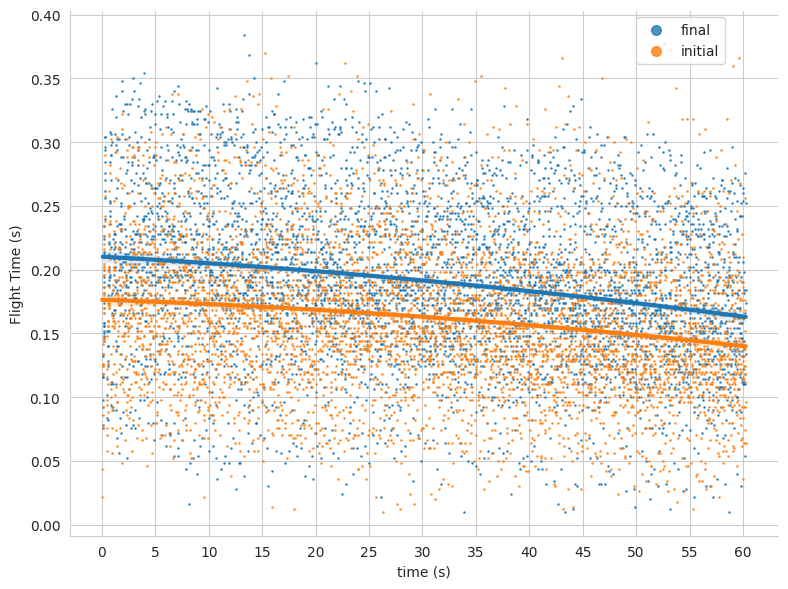

In [8]:
i=0
sns.set_style("whitegrid")
sns.lmplot(melt_df_list_timed[i].drop(melt_df_list_timed[i].loc[melt_df_list_timed[i].val>0.4].index),
           x='time', y='val', hue='Test', order = 2, x_ci='sd', legend=False,
           scatter_kws={"s": 0.75}, line_kws={"lw": 3},
           height=6, aspect=1.33).set(xticks=range(0, 65, 5))
plt.legend(loc=[0.8,0.9], markerscale=8)
plt.xlabel('time (s)')
plt.ylabel(dict[i])
#plt.savefig(dict[i]+' regression.svg')

Text(0, 0.5, 'Flight Time (s)')

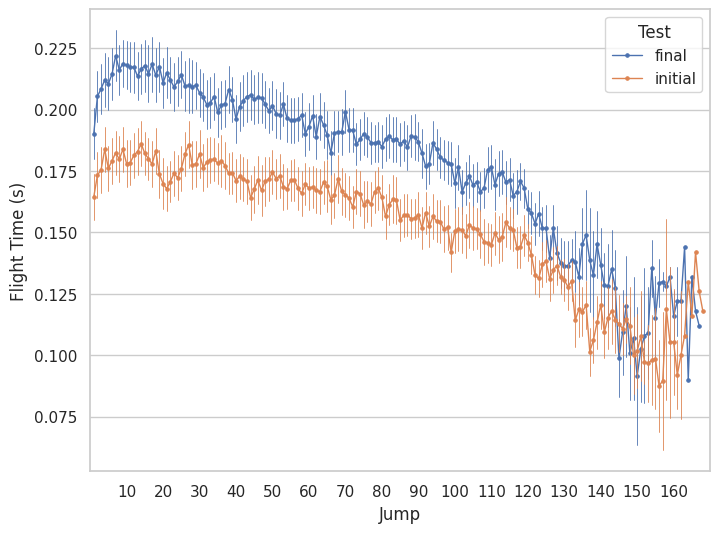

In [9]:
# Cannot use time because the function will attempt to aggregate all combinations, because time varies
# However NJump does not, so it can be aggregated
i=0
sns.set(rc={"figure.figsize":(8,6)})
sns.set_style("whitegrid")
sns.pointplot(melt_df_list_timed[i].drop(melt_df_list_timed[i].loc[melt_df_list_timed[i].val>0.4].index),
              x='Jump', y='val', hue='Test',
              estimator='mean', errorbar='se', legend=True, lw = 1,
              err_kws={'linewidth': 0.6}).set(xticks=range(-1, 170, 10))
# plt.xticks(ticks=[], labels=[])
plt.ylabel(dict[i])
#plt.savefig(dict[i]+' mean.svg')

Text(41.0, 0.5, 'distanta deviere (cm)')

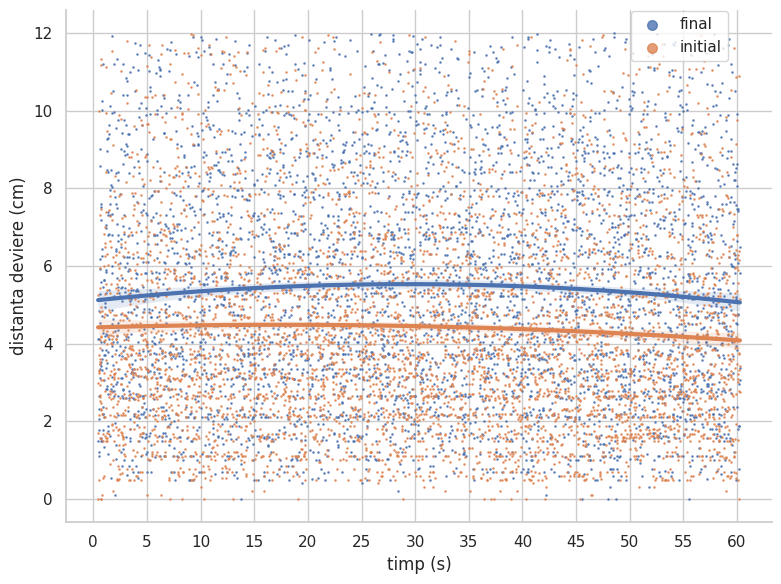

In [10]:
i=10
sns.set_style("whitegrid")
sns.lmplot(melt_df_list_timed[i].drop(melt_df_list_timed[i].loc[melt_df_list_timed[i].val>12].index),
           x='time', y='val', hue='Test', order = 2, x_ci='sd', legend=False,
           scatter_kws={"s": 0.75}, line_kws={"lw": 3},
           height=6, aspect=1.33).set(xticks=range(0, 65, 5))
plt.legend(loc=[0.8,0.9], markerscale=8)
plt.xlabel('timp (s)')
plt.ylabel(dict2[i])
# plt.savefig(dict2[i]+' - regresie.svg')
# plt.savefig('putere - regresie.svg')
# plt.savefig('viteza - regresie.svg')
# plt.savefig('IFR - regresie.svg')

Text(0, 0.5, 'distanta deviere (cm)')

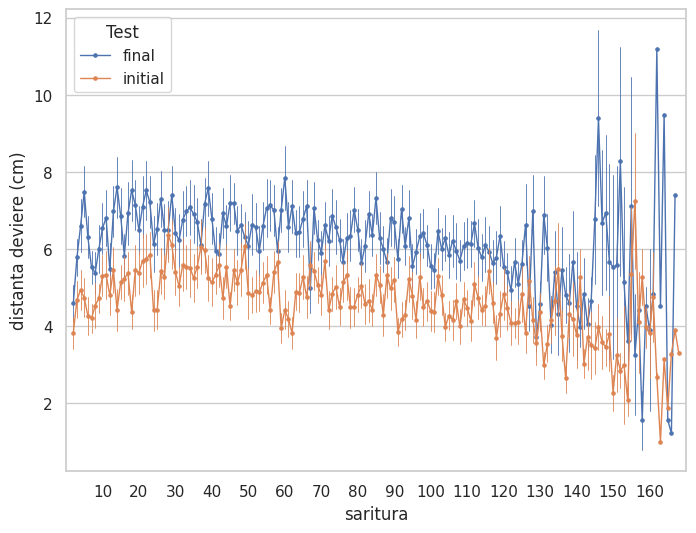

In [11]:
# Cannot use time because the function will attempt to aggregate all combinations, because time varies
# However NJump does not, so it can be aggregated
i=10
sns.set(rc={"figure.figsize":(8,6)})
sns.set_style("whitegrid")
sns.pointplot(melt_df_list_timed[i].drop(melt_df_list_timed[i].loc[melt_df_list_timed[i].val>20].index),
              x='Jump', y='val', hue='Test',
              estimator='mean', errorbar='se', legend=True, lw = 1,
              err_kws={'linewidth': 0.6}).set(xticks=range(-1, 170, 10))
plt.xlabel('saritura')
# plt.xticks(ticks=[], labels=[])
plt.ylabel(dict2[i])
# plt.savefig(dict2[i]+' - medie.svg')
# plt.savefig('putere - medie.svg')
# plt.savefig('viteza - medie.svg')
# plt.savefig('IFR - medie.svg')

In [12]:
wh = o.loc[:,['Name', 'Weight1', 'Height2']].copy()
wh.columns = ['Name', 'weight', 'height']

In [15]:
n = []
for df in melt_df_list_timed:
    ndf = df.copy()
    ndf = ndf.merge(wh, how='left')
    ndf.loc[:, 'bmi'] = 10000 * ndf.loc[:, 'weight'] / (ndf.loc[:, 'height']**2)
    ndf['nw'] = ndf.val.div(ndf.weight)
    ndf['nh'] = ndf.val.div(ndf.height)
    ndf['nbmi'] = ndf.val.div(ndf.bmi)
    n = n + [ndf]

In [16]:
n[0]

,Name,Test,Group,Sex,NJumps,Mean,Jump,val,time,weight,height,bmi,nw,nh,nbmi
0,o1,final,J,F,122,0.184123,1,0.262,0.262,69,158,27.639801,0.003797,0.001658,0.009479
1,o2,final,B,M,135,0.185348,1,0.226,0.226,70,157,28.398718,0.003229,0.001439,0.007958
2,o3,final,J,F,105,0.277067,1,0.294,0.294,67,156,27.531229,0.004388,0.001885,0.010679
3,o4,final,B,F,122,0.231131,1,0.304,0.304,63,151,27.630367,0.004825,0.002013,0.011002
4,o5,final,J,M,104,0.292692,1,0.304,0.304,58,146,27.209608,0.005241,0.002082,0.011173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13515,o36,initial,B,M,135,0.140178,169,NaN,NaN,79,158,31.645570,NaN,NaN,NaN
13516,o37,initial,J,M,149,0.159866,169,NaN,NaN,66,145,31.391201,NaN,NaN,NaN
13517,o38,initial,J,M,133,0.138451,169,NaN,NaN,74,165,27.180900,NaN,NaN,NaN
13518,o39,initial,B,M,161,0.171093,169,NaN,NaN,72,158,28.841532,NaN,NaN,NaN


Text(36.0, 0.5, 'Flight Time (s)')

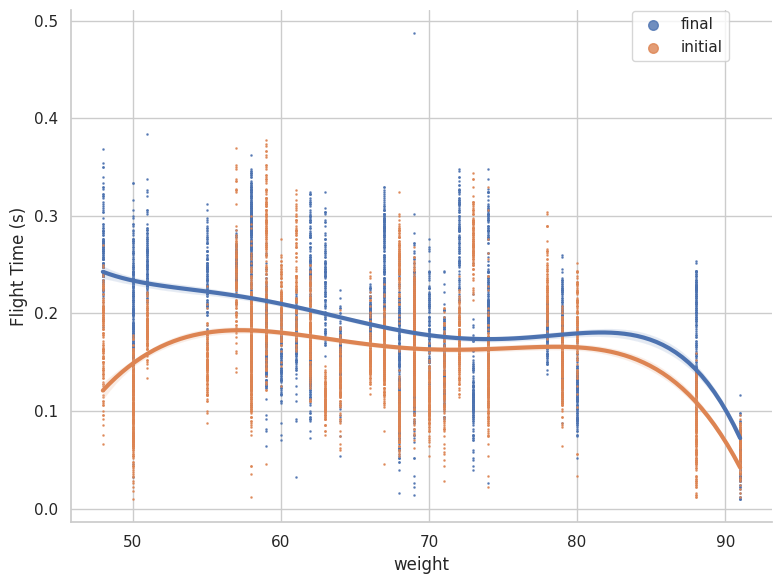

In [62]:
i=0
sns.set_style("whitegrid")
sns.lmplot(n[i],
           x='weight', y='val', hue='Test', order = 5, x_ci='sd', legend=False,
           scatter_kws={"s": 0.75}, line_kws={"lw": 3},
           height=6, aspect=1.33)
# .set(xticks=range(0, 65, 5))
plt.legend(loc=[0.8,0.9], markerscale=8)
# plt.xlabel('time (s)')
plt.ylabel(dict[i])
#plt.savefig(dict[i]+' regression.svg')

In [42]:
smf.ols('val ~ Test', data = n[2]).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    val   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     563.7
Date:                Fri, 05 Sep 2025   Prob (F-statistic):          1.97e-121
Time:                        02:18:33   Log-Likelihood:                -25660.
No. Observations:               10559   AIC:                         5.132e+04
Df Residuals:                   10557   BIC:                         5.134e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           4.8671      0.038    127.575      0.000       4.792       4.942
Test[T.initial]    -1.2706      0.054    -23.742      0.000      -1.375      -1.166
==============================================================================
Omnibus:                     2072.085   Durbin-Watson:                   1.805
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4140.115
Skew:                           1.179   Prob(JB):                         0.00
Kurtosis:                       4.961   Cond. No.                         2.64
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""